# 01 - Data and EDA
**Two datasets, never mixed.**

| | REAL public data | SYNTHETIC (simulated) data |
|---|---|---|
| source | CFAA milling tests, Zenodo 10.5281/zenodo.14445879 (CC BY 4.0), Ibarmia + GMTK machining centres | `src/synth_generator.py`, seed 42 |
| what it is | measured spindle power with speed, override, axis loads | first-principles power model + hidden factors + noise + injected inefficiencies |
| limits | no feed/depth/torque/timestamps/run ids, balanced subsample, 13 % duplicates | correct by construction only inside the simulator's assumptions |
| role | sanity check and honest limits | main experimental engine, anomaly labels, optimisation |

In [1]:
import sys, json, warnings
from pathlib import Path
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
from IPython.display import Image, display, Markdown
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30); pd.set_option("display.max_colwidth", 60)
FIG, TAB, RES = ROOT/"results/figures", ROOT/"results/tables", ROOT/"experiments/results"
def show(name, width=760): display(Image(filename=str(FIG/name), width=width))

In [2]:
raw = {k: pd.read_csv(ROOT/'data/raw'/f) for k, f in [('ibarmia','IBARMIA_dataset.csv'), ('gmtk','GMTK_dataset.csv')]}
display(Markdown('### REAL - Ibarmia head')); display(raw['ibarmia'].head())
display(Markdown('### REAL - summary')); display(pd.concat({k: v.describe().T[['mean','std','min','max']] for k, v in raw.items()}).round(3))
syn = pd.read_csv(ROOT/'data/synthetic/synthetic_machining_windows.csv')
display(Markdown('### SYNTHETIC - head (columns starting with gt_ are ground truth, never features)')); display(syn.head())
print(json.dumps(json.load(open(ROOT/'data/processed/synthetic_prep_report.json')), indent=1))

### REAL - Ibarmia head

,load_X,load_Z,power_Z,speed_SPINDLE,override_SPINDLE,powerDrive_SPINDLE,power_consumption
0,1.422119,9.051514,3.239576,605.850220,100.000000,0.042884,Low
1,1.165771,1.208496,3.239576,2765.178680,100.000000,1.295703,Medium
2,2.430502,6.601554,-651.218164,3990.048322,105.025987,2.321362,High
3,1.214600,7.366943,-12.958302,2749.099731,100.000000,2.955727,High
4,0.732297,1.353466,6.480702,2754.417736,100.064190,0.347926,High


### REAL - summary

mean       std        min        max
ibarmia load_X                 1.924     2.825     -0.148     44.144
        load_Z                 9.752     5.208     -0.073     33.423
        power_Z              624.587  1618.989  -1992.448   9171.263
        speed_SPINDLE       2108.641  1287.690      7.854   5000.610
        override_SPINDLE     100.153     2.356     50.000    110.112
        powerDrive_SPINDLE     1.445     2.137     -0.106     19.249
gmtk    load_X                17.368     0.997      1.306     34.338
        load_Z                14.665     7.644      0.638     98.792
        power_Z              145.456  1949.392 -28016.111  30740.736
        speed_SPINDLE         -2.539    13.903   -120.048     12.129
        override_SPINDLE      82.214    32.952      4.858    120.126
        powerDrive_SPINDLE     0.723     1.922     -0.156     30.824

### SYNTHETIC - head (columns starting with gt_ are ground truth, never features)

,job_id,window_idx,material,spindle_speed_rpm,axis_speed_mm_min,feed_per_tooth_mm,axial_depth_mm,radial_width_mm,tool_diameter_mm,n_flutes,coolant_mode,tool_age_min,machine_on_min,ambient_temp_c,spindle_load_pct,...,job_mrr_cm3_min,gt_state,gt_job_anomaly,gt_extra_kw,gt_power_true_kw,gt_power_nominal_kw,gt_is_inefficient,gt_is_glitch,gt_wear_vb,gt_p_base,gt_p_coolant,gt_p_idle,gt_p_cut,gt_p_axes,energy_wh
0,0,0,SS316L,0.0000,0.0000,0.000000,0.000000,0.000000,6.0,5,0,81.1728,226.8079,25.365,0.0000,...,2.8745,standby,none,0.0,2.7873,2.7873,False,False,0.121192,2.4073,0.00,0.0800,0.0000,0.3000,7.611
1,0,1,SS316L,4019.2005,23734.4688,0.000000,0.000000,0.000000,6.0,5,2,81.1728,226.9746,25.365,6.7870,...,2.8745,rapid,none,0.0,9.1028,9.1028,False,False,0.121192,2.4073,4.20,1.2955,0.0000,1.2000,25.778
2,0,2,SS316L,4027.8527,1056.2298,0.051562,0.000000,0.000000,6.0,5,2,81.1728,227.1413,25.365,6.7418,...,2.8745,aircut,none,0.0,8.2419,8.2419,False,False,0.121192,2.4073,4.20,1.2955,0.0000,0.3391,22.833
3,0,3,SS316L,4039.4319,1045.4709,0.051562,1.832579,1.505337,6.0,5,2,81.6728,227.3079,25.365,9.0515,...,2.8745,cutting,none,0.0,8.8699,8.8699,False,False,0.121192,2.4073,4.55,1.2955,0.2763,0.3407,24.333
4,0,4,SS316L,4056.8219,1044.6952,0.051562,1.832579,1.505337,6.0,5,2,81.8394,227.4746,25.365,8.3181,...,2.8745,cutting,none,0.0,8.8670,8.8670,False,False,0.121192,2.4073,4.55,1.2955,0.2735,0.3407,24.806


{
 "rows_raw": 27027,
 "rows_clean": 26967,
 "dropped_dropouts": 60,
 "mrr_q88": 197.001896,
 "mrr_q94": 244.616934,
 "rows_per_split": {
  "train": 14169,
  "test": 4765,
  "val": 4744,
  "ood_val": 1656,
  "ood_test": 1633
 },
 "jobs_per_split": {
  "train": 1320,
  "val": 440,
  "test": 440,
  "ood_test": 150,
  "ood_val": 150
 },
 "max_train_mrr": 196.4372
}


## Where does the power go? (synthetic)

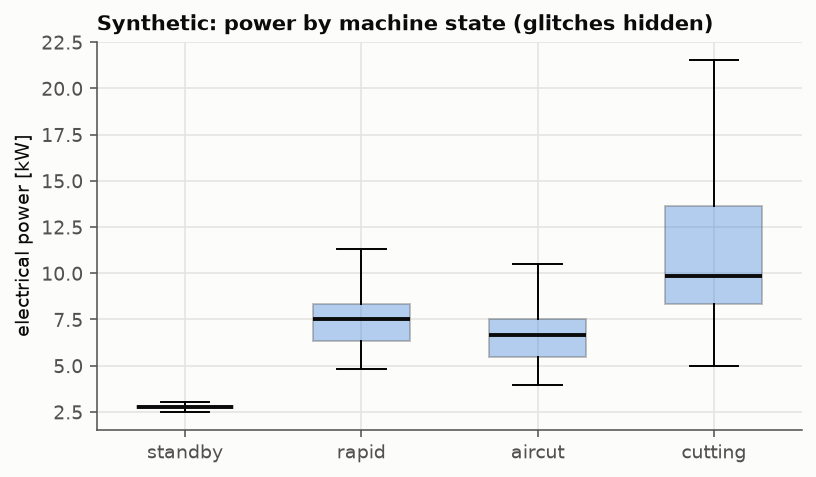

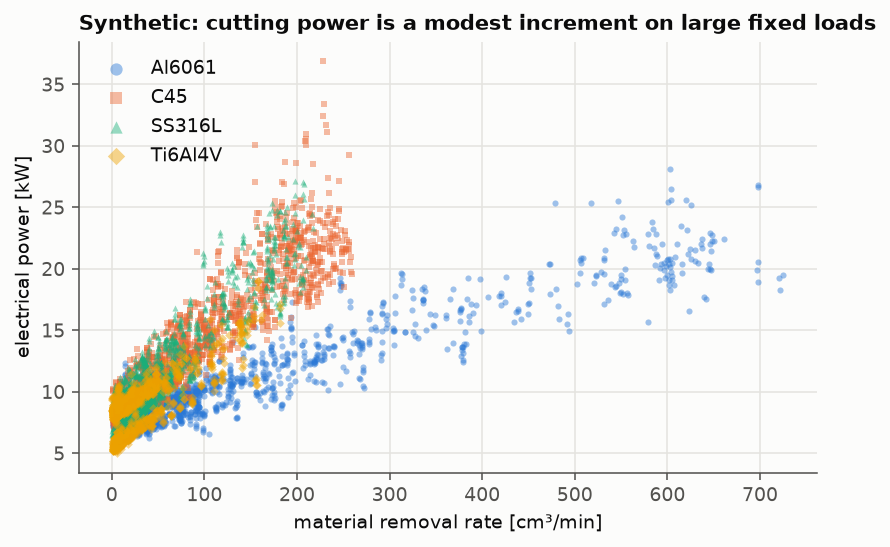

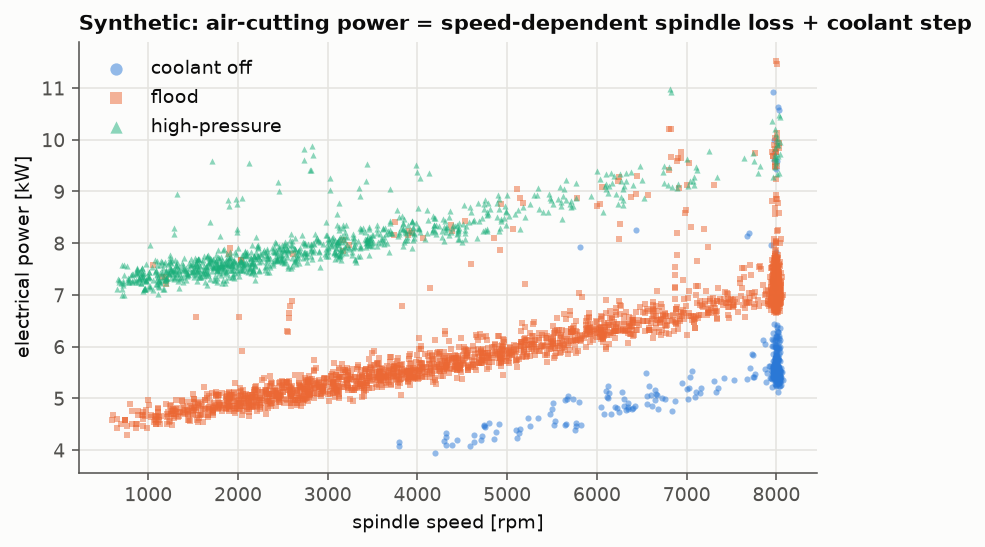

In [3]:
show('e01_power_by_state.png', 620); show('e01_power_vs_mrr.png', 700); show('e01_aircut_power_vs_speed.png', 700)

In [4]:
e = json.load(open(RES/'E01_eda.json'))
s = e['synthetic_summary']
print('mean power by state [kW]:', s['mean_power_by_state'])
print('inside a cutting window [kW]:', s['cutting_power_decomposition_kw'])
print('oracle floor (true noise-free power vs metered), validation:', {k: round(v, 3) for k, v in s['oracle_floor_val'].items()})

mean power by state [kW]: {'aircut': 6.64, 'cutting': 11.62, 'rapid': 7.5, 'standby': 2.8}
inside a cutting window [kW]: {'gt_p_base': 2.4, 'gt_p_coolant': 2.45, 'gt_p_idle': 1.71, 'gt_p_cut': 4.62, 'gt_p_axes': 0.38}
oracle floor (true noise-free power vs metered), validation: {'mae': 0.165, 'rmse': 0.876, 'r2': 0.954, 'mape': 1.565, 'n': 4744}


## Leakage audit
Electrical measurements are the target in disguise (P = sqrt(3)·V·I·cos φ). Planning models use **commanded** conditions only.

In [5]:
pd.DataFrame(e['leakage_audit_synthetic_val']).T[['mae','rmse','r2','mape']].round(3)

,mae,rmse,r2,mape
identity_sqrt3*V*I*cosphi (no fit),0.171,0.878,0.954,1.631
linear: commanded features only (planning set),1.492,2.194,0.713,17.414
linear: commanded + drive load signals,0.391,0.996,0.941,4.464
"linear: commanded + V, I, cos(phi) [LEAKAGE]",0.221,0.887,0.953,2.391
"linear: V, I, cos(phi) only [LEAKAGE]",0.180,0.876,0.954,1.740


## Splits: extrapolation bands in material-removal rate

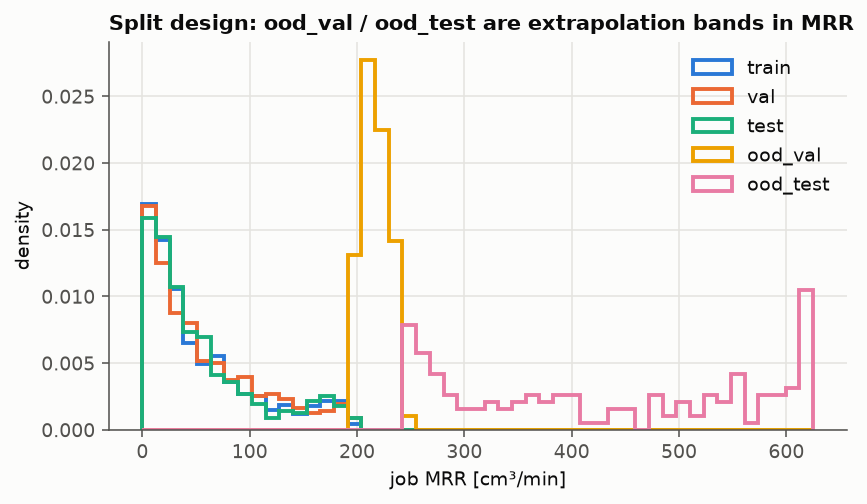

In [6]:
show('e01_split_mrr.png', 700)

## Real data: what is in it, and what is not

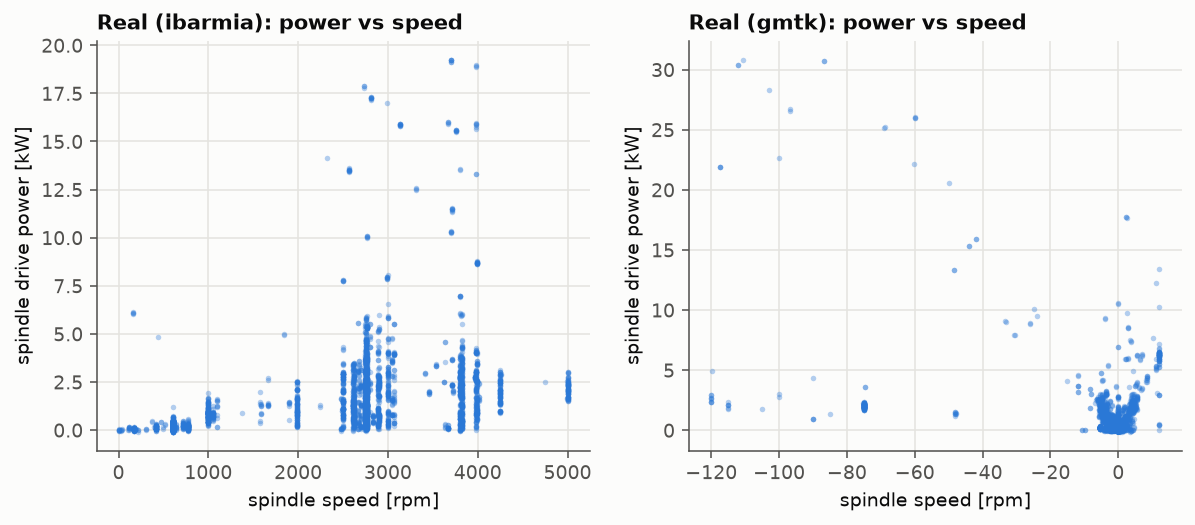

In [7]:
show('e01_real_power_vs_speed.png', 900)

In [8]:
r = e['real']
for k, v in r.items():
    print(k, '| duplicates:', v['duplicates'], '| share rows |speed|>100rpm:', round(v['frac_rows_spindle_abs_speed_gt_100rpm'], 3),
          '| R2 of Low/Med/High class means vs spindle power:', round(v['r2_of_class_means'], 3))
    print('   correlation with spindle power:', v['corr_with_power'])

ibarmia | duplicates: 801 | share rows |speed|>100rpm: 0.998 | R2 of Low/Med/High class means vs spindle power: 0.186
   correlation with spindle power: {'load_X': 0.063, 'load_Z': -0.12, 'power_Z': 0.207, 'speed_SPINDLE': 0.463, 'override_SPINDLE': 0.079, 'powerDrive_SPINDLE': 1.0}
gmtk | duplicates: 800 | share rows |speed|>100rpm: 0.004 | R2 of Low/Med/High class means vs spindle power: 0.105
   correlation with spindle power: {'load_X': 0.068, 'load_Z': 0.426, 'power_Z': 0.265, 'speed_SPINDLE': -0.369, 'override_SPINDLE': -0.032, 'powerDrive_SPINDLE': 1.0}


## Can the real data support predictive claims? (E14)
Tree models reach R² ≈ 0.75 with a random split, but the score collapses when neighbouring records cannot leak between train and test.

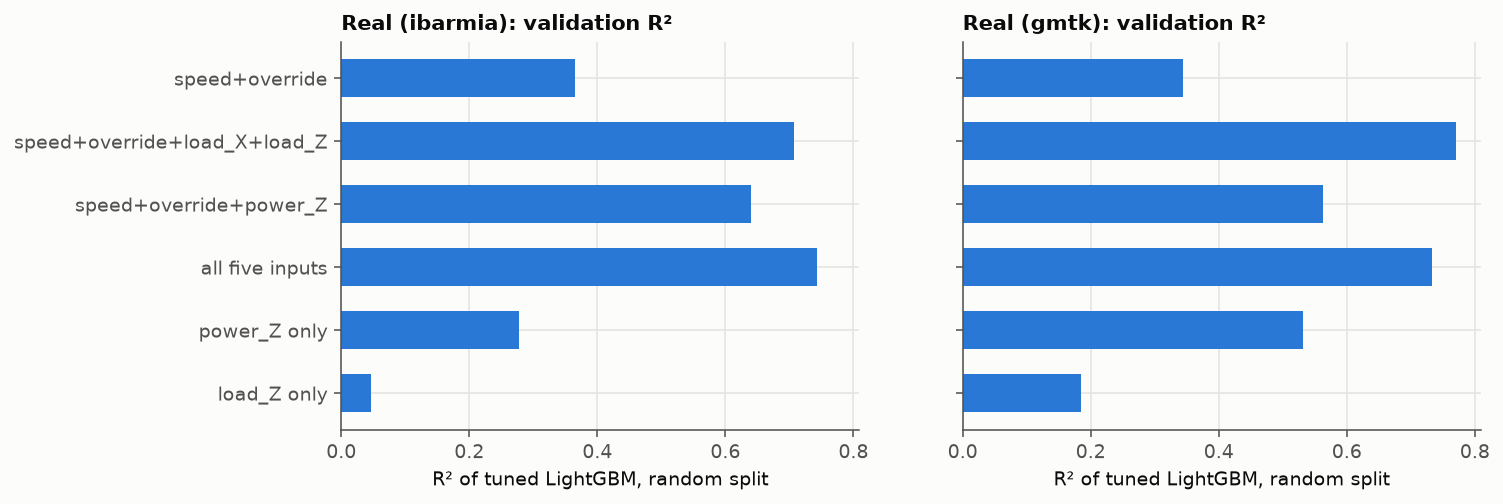

In [9]:
show('e14_real_feature_subsets.png', 900)

In [10]:
p = json.load(open(RES/'E14_real_data_probes.json'))
pd.DataFrame({k: {'random 5-fold R2': v['cv_random_5fold']['r2'], 'cluster-grouped 5-fold R2': v['cv_cluster_grouped_5fold']['r2'],
                  '1-NN regressor val R2': v['nn']['one_nn_regressor_val']['r2'],
                  'val rows with train neighbour < 0.05 std': v['nn']['share_val_with_nn_dist_lt_0p05']} for k, v in p.items()}).round(3)

,ibarmia,gmtk
random 5-fold R2,0.846,0.851
cluster-grouped 5-fold R2,-0.130,-1.429
1-NN regressor val R2,0.643,0.717
val rows with train neighbour < 0.05 std,0.838,0.698
